# Olist Initial Purchase Random Forest

## Project objective

This notebook builds a **baseline Random Forest classifier** for predicting whether a customer makes a repeat purchase within 90 days of their initial purchase. It deliberately preserves the Logistic Regression experiment's source table, complete-case population, eight raw predictors, chronological split, customers, leakage protections, target, and evaluation population. This makes the results an apples-to-apples algorithm comparison.

A Random Forest combines predictions from many decision trees. Each tree learns nonlinear splits and interactions from a bootstrap sample while considering a random subset of features. Averaging the trees usually makes the result more stable than one decision tree. We test it after Logistic Regression to see whether nonlinear relationships or interactions provide useful signal without adding features or changing the experiment.

In [1]:
# Core libraries handle tabular data, calculations, and the importance chart.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SQLAlchemy loads the prepared PostgreSQL table; scikit-learn supplies preprocessing, modeling, and evaluation tools.
from sqlalchemy import create_engine
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, precision_recall_curve, auc,
    average_precision_score
)

## Load the modeling table

The data is read without changing PostgreSQL. The source is exactly `customer_initial_purchase_model`, as in the Logistic Regression notebook.

In [2]:
# Create a reusable connection to the local PostgreSQL database that holds the modeling table.
engine = create_engine("postgresql+psycopg2://marcusromeo@localhost:5432/olist_project")
# Load the already-prepared customer-level table into a DataFrame for analysis in Python.
df = pd.read_sql("SELECT * FROM customer_initial_purchase_model", engine)
print(f"Loaded {len(df):,} customers and {df.shape[1]} columns.")
df.head()

Loaded 86,924 customers and 13 columns.


,customer_unique_id,repeat_purchase_90d,customer_state,first_order_date,first_order_amount,product_amount,freight_amount,products_ordered,unique_products_ordered,number_of_categories,number_of_sellers,payment_installments,freight_to_order_ratio
0,0000366f3b9a7992bf8c76cfdf3221e2,No,SP,2018-05-10 10:56:27,141.90,129.90,12.00,1.0,1.0,1.0,1.0,8.0,0.084567
1,0000b849f77a49e4a4ce2b2a4ca5be3f,No,SP,2018-05-07 11:11:27,27.19,18.90,8.29,1.0,1.0,1.0,1.0,1.0,0.304892
2,0000f46a3911fa3c0805444483337064,No,SC,2017-03-10 21:05:03,86.22,69.00,17.22,1.0,1.0,1.0,1.0,8.0,0.199722
3,0000f6ccb0745a6a4b88665a16c9f078,No,PA,2017-10-12 20:29:41,43.62,25.99,17.63,1.0,1.0,1.0,1.0,4.0,0.404172
4,0004aac84e0df4da2b147fca70cf8255,No,SP,2017-11-14 19:45:42,196.89,180.00,16.89,1.0,1.0,1.0,1.0,6.0,0.085784


## Preserve the complete-case modeling population

These baselines keep the original complete-case approach: first remove rows without an initial-order amount, then remove rows with any remaining missing value. The corrected SQL table can legitimately change the resulting population, so the notebook reports the refreshed counts instead of asserting historical totals. This keeps all three baseline models comparable without introducing imputation in this controlled refresh.

In [3]:
# Preserve the historical complete-case baseline without hard-coding population counts from the pre-correction table.
df_model = df.dropna(subset=["first_order_amount"])
df_final = df_model.dropna().copy()

# Verify the expected table layout and that the modeling population has no remaining missing values.
assert df.shape[1] == 13
assert not df_final.isna().any().any()
print(f"Source population: {len(df):,} customers")
print(f"Final complete-case population: {len(df_final):,} customers")

Source population: 86,924 customers
Final complete-case population: 86,268 customers


## Target, predictors, and leakage protection

The target remains `repeat_purchase_90d` (No = 0, Yes = 1). The same eight raw predictors describe only the customer and initial purchase. Customer ID, the split date, target, and other table columns are excluded from model inputs. Preprocessing will be fit on training customers only, protecting the future testing period from leakage.

In [4]:
# Predictors describe only the initial purchase, keeping later behavior out of the model and avoiding leakage.
feature_columns = [
    "customer_state",
    "first_order_amount",
    "freight_to_order_ratio",
    "products_ordered",
    "unique_products_ordered",
    "number_of_categories",
    "number_of_sellers",
    "payment_installments",
]
# The target records the outcome the model should learn: whether a repeat purchase occurred within 90 days.
target_column = "repeat_purchase_90d"
print(f"Raw predictors ({len(feature_columns)}): {feature_columns}")

Raw predictors (8): ['customer_state', 'first_order_amount', 'freight_to_order_ratio', 'products_ordered', 'unique_products_ordered', 'number_of_categories', 'number_of_sellers', 'payment_installments']


## Preserve the chronological train/test split

The cutoff is the same 80th-percentile observation used by the Logistic Regression notebook. Earlier customers (including the cutoff timestamp) form training data; later customers form the untouched test population. Customer IDs are compared with independently reconstructed reference masks to confirm exact membership.

In [5]:
# Split by time so training uses the earliest roughly 80% of customers and testing mimics predictions on later customers.
cutoff_date = df_final["first_order_date"].sort_values().iloc[int(len(df_final) * 0.80)]
train = df_final[df_final["first_order_date"] <= cutoff_date].copy()
test = df_final[df_final["first_order_date"] > cutoff_date].copy()

# X contains only prediction-time-safe initial-purchase features; y is the repeat-purchase outcome.
X_train, X_test = train[feature_columns], test[feature_columns]
y_train = train[target_column].map({"No": 0, "Yes": 1})
y_test = test[target_column].map({"No": 0, "Yes": 1})

assert list(X_train.columns) == feature_columns
assert list(X_test.columns) == feature_columns
assert not X_train.isna().any().any() and not X_test.isna().any().any()

for label, y in [("Train", y_train), ("Test", y_test)]:
    positives = int(y.sum())
    print(f"{label}: {len(y):,} rows | {positives:,} positives | {len(y) - positives:,} negatives | repeat rate: {y.mean():.4%}")
print(f"Chronological cutoff timestamp: {cutoff_date}")

Train: 69,015 rows | 1,458 positives | 67,557 negatives | repeat rate: 2.1126%
Test: 17,253 rows | 226 positives | 17,027 negatives | repeat rate: 1.3099%
Chronological cutoff timestamp: 2018-04-24 09:10:20


## Random-Forest preprocessing

`customer_state` remains one-hot encoded with unknown states ignored, which converts it to numeric indicators compatible with scikit-learn and safely handles a state that might appear only in testing. Numeric predictors pass through unchanged: tree models split on ordered values and do not require `StandardScaler`. The transformer is fit only on training data, then applied to both periods.

In [6]:
# State is categorical; every other selected predictor is already numeric.
categorical_features = ["customer_state"]
numeric_features = [column for column in feature_columns if column not in categorical_features]

# ColumnTransformer applies the appropriate preparation to each feature type in one consistent object.
preprocessor = ColumnTransformer(
    transformers=[
        # Tree splits do not depend on feature scale, so numeric columns can pass through unchanged.
        ("numeric", "passthrough", numeric_features),
        # One-hot encoding gives each state its own indicator; ignore unseen test states instead of failing.
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
# Learn encoding categories only from training data to prevent test information from leaking into preprocessing.
X_train_processed = preprocessor.fit_transform(X_train)
# Reuse the fitted training transformation so test data is represented by exactly the same columns.
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print(f"Processed shapes: train {X_train_processed.shape}, test {X_test_processed.shape}")
print(feature_names)

Processed shapes: train (69015, 34), test (17253, 34)
['numeric__first_order_amount' 'numeric__freight_to_order_ratio'
 'numeric__products_ordered' 'numeric__unique_products_ordered'
 'numeric__number_of_categories' 'numeric__number_of_sellers'
 'numeric__payment_installments' 'categorical__customer_state_AC'
 'categorical__customer_state_AL' 'categorical__customer_state_AM'
 'categorical__customer_state_AP' 'categorical__customer_state_BA'
 'categorical__customer_state_CE' 'categorical__customer_state_DF'
 'categorical__customer_state_ES' 'categorical__customer_state_GO'
 'categorical__customer_state_MA' 'categorical__customer_state_MG'
 'categorical__customer_state_MS' 'categorical__customer_state_MT'
 'categorical__customer_state_PA' 'categorical__customer_state_PB'
 'categorical__customer_state_PE' 'categorical__customer_state_PI'
 'categorical__customer_state_PR' 'categorical__customer_state_RJ'
 'categorical__customer_state_RN' 'categorical__customer_state_RO'
 'categorical__cust

## Train the baseline Random Forest

The model uses every `RandomForestClassifier` default except `random_state=42`, which makes the bootstrap sampling and feature selection reproducible. There is no tuning, cross-validation, resampling, SMOTE, class weighting, threshold change, feature engineering, or additional feature removal.

In [7]:
# Build the Random Forest; random_state=42 makes its sampling and feature randomness reproducible.
model = RandomForestClassifier(random_state=42)
# Fit lets the forest learn decision rules from the processed training features and known outcomes.
model.fit(X_train_processed, y_train)
model

RandomForestClassifier(random_state=42)

## Standardized training and test evaluation

All class metrics use the unchanged default 0.50 threshold. ROC-AUC and Average Precision use predicted probabilities and evaluate ranking quality across thresholds. Average Precision is the primary precision-recall summary and should be interpreted against the positive-class prevalence. Training metrics are diagnostic; the later chronological test set remains the generalization comparison.

In [8]:
# Calculate thresholded and probability-ranking metrics identically for training and chronological test data.
def evaluate_model(y_true, predictions, probabilities):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, probabilities)
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "Average Precision": average_precision_score(y_true, probabilities),
        # Retained only as a clearly labelled curve integral; it is not Average Precision.
        "Trapezoidal PR-AUC": auc(recall_curve, precision_curve),
        "Predicted positives at 0.50": int(predictions.sum()),
        "Positive-class prevalence": y_true.mean(),
    }

y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)
y_train_proba = model.predict_proba(X_train_processed)[:, 1]
y_test_proba = model.predict_proba(X_test_processed)[:, 1]

train_metrics = evaluate_model(y_train, y_train_pred, y_train_proba)
test_metrics = evaluate_model(y_test, y_test_pred, y_test_proba)
metrics_table = pd.DataFrame([train_metrics, test_metrics], index=["Training", "Test"])
display(metrics_table)

print("Training confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_train, y_train_pred))
print("\nTest confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, y_test_pred))
print(f"\nROC-AUC train-test gap: {train_metrics['ROC-AUC'] - test_metrics['ROC-AUC']:.4f}")
print(f"Average Precision train-test gap: {train_metrics['Average Precision'] - test_metrics['Average Precision']:.4f}")

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Trapezoidal PR-AUC,Predicted positives at 0.50,Positive-class prevalence
Training,0.994001,0.98785,0.724966,0.836234,0.997081,0.931756,0.931907,1070,0.021126
Test,0.985452,0.00000,0.000000,0.000000,0.512549,0.013830,0.013812,25,0.013099


Training confusion matrix [[TN, FP], [FN, TP]]:
[[67544    13]
 [  401  1057]]

Test confusion matrix [[TN, FP], [FN, TP]]:
[[17002    25]
 [  226     0]]

ROC-AUC train-test gap: 0.4845
Average Precision train-test gap: 0.9179


In [9]:
# Print the current test metrics with the same terminology used in the standardized table.
print(f"Test accuracy: {test_metrics['Accuracy']:.3%}")
print(f"Test positive-class precision: {test_metrics['Precision']:.4f}")
print(f"Test positive-class recall: {test_metrics['Recall']:.4f}")
print(f"Test positive-class F1: {test_metrics['F1']:.4f}")
print(f"Test ROC-AUC: {test_metrics['ROC-AUC']:.4f}")
print(f"Test Average Precision: {test_metrics['Average Precision']:.4f}")
print(f"Positive predictions at 0.50: {test_metrics['Predicted positives at 0.50']:,}")

Test accuracy: 98.545%
Test positive-class precision: 0.0000
Test positive-class recall: 0.0000
Test positive-class F1: 0.0000
Test ROC-AUC: 0.5125
Test Average Precision: 0.0138
Positive predictions at 0.50: 25


## Feature importance

Impurity-based importance summarizes how much each processed feature reduced tree impurity across the forest. The chart shows every numeric predictor and every state indicator; the table also aggregates the state indicators back to the raw `customer_state` feature for an eight-predictor view. Importance can favor continuous or high-cardinality features and **does not imply causation**, effect direction, or business impact.

,importance
freight_to_order_ratio,0.442321
first_order_amount,0.434947
payment_installments,0.057598
customer_state,0.042408
products_ordered,0.012898
unique_products_ordered,0.005506
number_of_sellers,0.002589
number_of_categories,0.001734


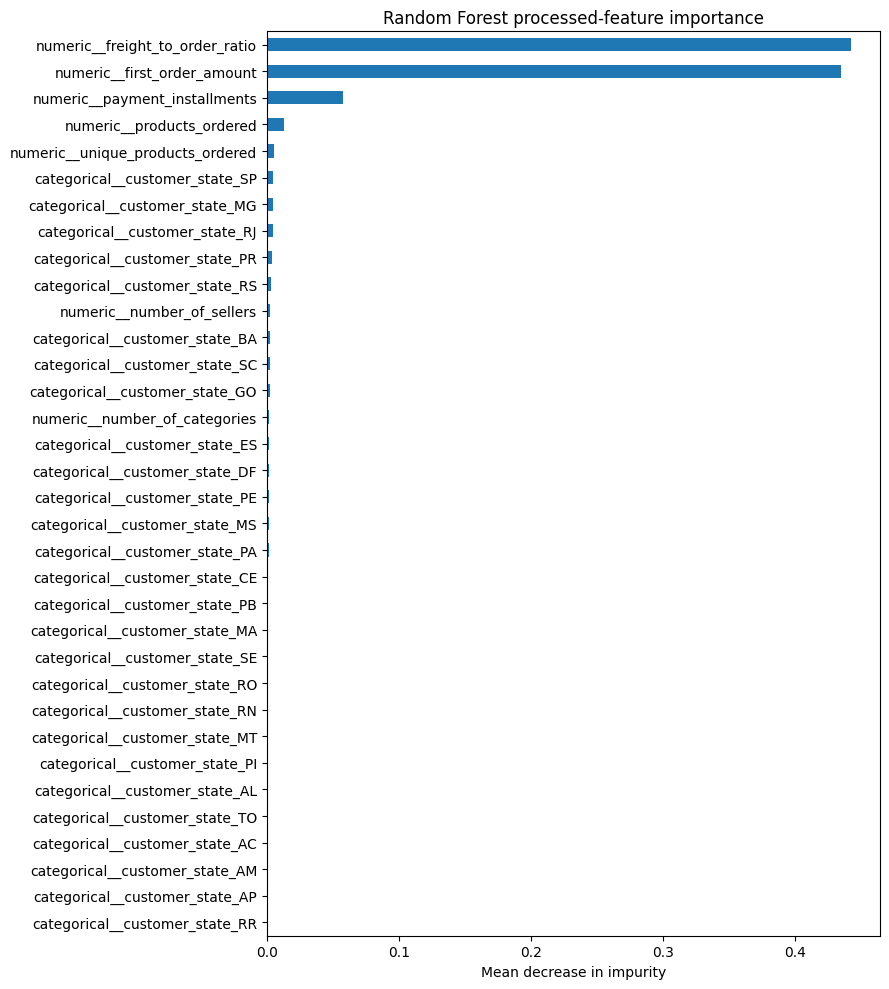

In [10]:
# Forest importance measures how much each processed feature reduces impurity across the trees.
processed_importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
# Sum all one-hot state indicators to recover one overall importance for the original customer_state feature.
raw_importance = pd.Series({
    **{column: processed_importance[f"numeric__{column}"] for column in numeric_features},
    "customer_state": processed_importance[processed_importance.index.str.startswith("categorical__customer_state_")].sum(),
}).sort_values(ascending=False)
display(raw_importance.rename("importance").to_frame())

processed_importance.sort_values().plot.barh(figsize=(9, 10), title="Random Forest processed-feature importance")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## Cross-model comparison

All three corrected baselines use the same chronological split and original eight-predictor feature set. A repository-level summary will compare their refreshed saved results after every notebook has executed; this notebook avoids carrying forward pre-correction model metrics.

In [11]:
# Cross-model comparison is intentionally deferred until all corrected baseline notebooks have been executed.
# This controlled refresh reports this model's own corrected results without carrying forward historical outputs.
metrics_table

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Trapezoidal PR-AUC,Predicted positives at 0.50,Positive-class prevalence
Training,0.994001,0.98785,0.724966,0.836234,0.997081,0.931756,0.931907,1070,0.021126
Test,0.985452,0.00000,0.000000,0.000000,0.512549,0.013830,0.013812,25,0.013099


In [12]:
# Compare training and test ranking performance: a large gap can indicate overfitting, while weak values on both can indicate limited signal.
roc_gap = train_metrics["ROC-AUC"] - test_metrics["ROC-AUC"]
ap_gap = train_metrics["Average Precision"] - test_metrics["Average Precision"]
print(f"ROC-AUC train-test gap: {roc_gap:.4f}")
print(f"Average Precision train-test gap: {ap_gap:.4f}")
print("Interpret gaps alongside absolute test performance and the chronological change in repeat prevalence; a gap alone is not proof of overfitting.")

ROC-AUC train-test gap: 0.4845
Average Precision train-test gap: 0.9179
Interpret gaps alongside absolute test performance and the chronological change in repeat prevalence; a gap alone is not proof of overfitting.


## Interpretation

Use the executed outputs above as the reproducible record of this corrected baseline. High accuracy can mostly reflect predicting non-repeat purchasers because the target is rare. Interpret Average Precision relative to the positive-class prevalence, and distinguish probability ranking (ROC-AUC and Average Precision) from default-threshold classification metrics.

A large training advantage together with weak chronological test performance suggests overfitting; weak training and test performance suggests limited usable signal in the original first-purchase feature set. Feature importance is descriptive and model-specific, not causal. Threshold selection, class balancing, tuning, time-aware validation, and enriched features are intentionally outside this refresh.